## Import required python packages

In [1]:
import pandas as pd
from causalimpact import CausalImpact

## Import and create data

#### Import data tables

In [2]:
transactions = pd.read_excel("data/grocery_database.xlsx", sheet_name = "transactions")
campaign_data = pd.read_excel("data/grocery_database.xlsx", sheet_name = "campaign_data")

#### Aggregate transactions data to customer, data level

In [3]:
customer_daily_sales = transactions.groupby(["customer_id", "transaction_date"])["sales_cost"].sum().reset_index()

#### Merge on the signup flag

In [4]:
customer_daily_sales = pd.merge(customer_daily_sales, campaign_data, how = "inner", on = "customer_id")

#### Pivot the date to aggregate daily sales by signup group

In [5]:
causal_impact_df = customer_daily_sales.pivot_table(index = "transaction_date",
                                                   columns = "signup_flag",
                                                   values = "sales_cost",
                                                   aggfunc = "mean")

#### Provide a frequency for our DateTimeIndex (avoids a warning message)

In [6]:
causal_impact_df.index.freq = "D"

#### For causal impact we need the impacted group in the first column

In [7]:
causal_impact_df = causal_impact_df[[1, 0]]

#### Rename columns to something more meaningful

In [8]:
causal_impact_df.columns = ["member", "non_member"]

## Apply Causal Impact

In [9]:
pre_period = ["2020-04-01", "2020-06-30"]
post_period = ["2020-07-01", "2020-09-30"]

ci = CausalImpact(causal_impact_df, pre_period, post_period)

/opt/anaconda3/lib/python3.13/site-packages/causalimpact/main.py:603: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  if not data.applymap(np.isreal).values.all():
/opt/anaconda3/lib/python3.13/site-packages/causalimpact/main.py:302: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  self.mu_sig = (mu[0], sig[0])
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, m

## Plot the impact

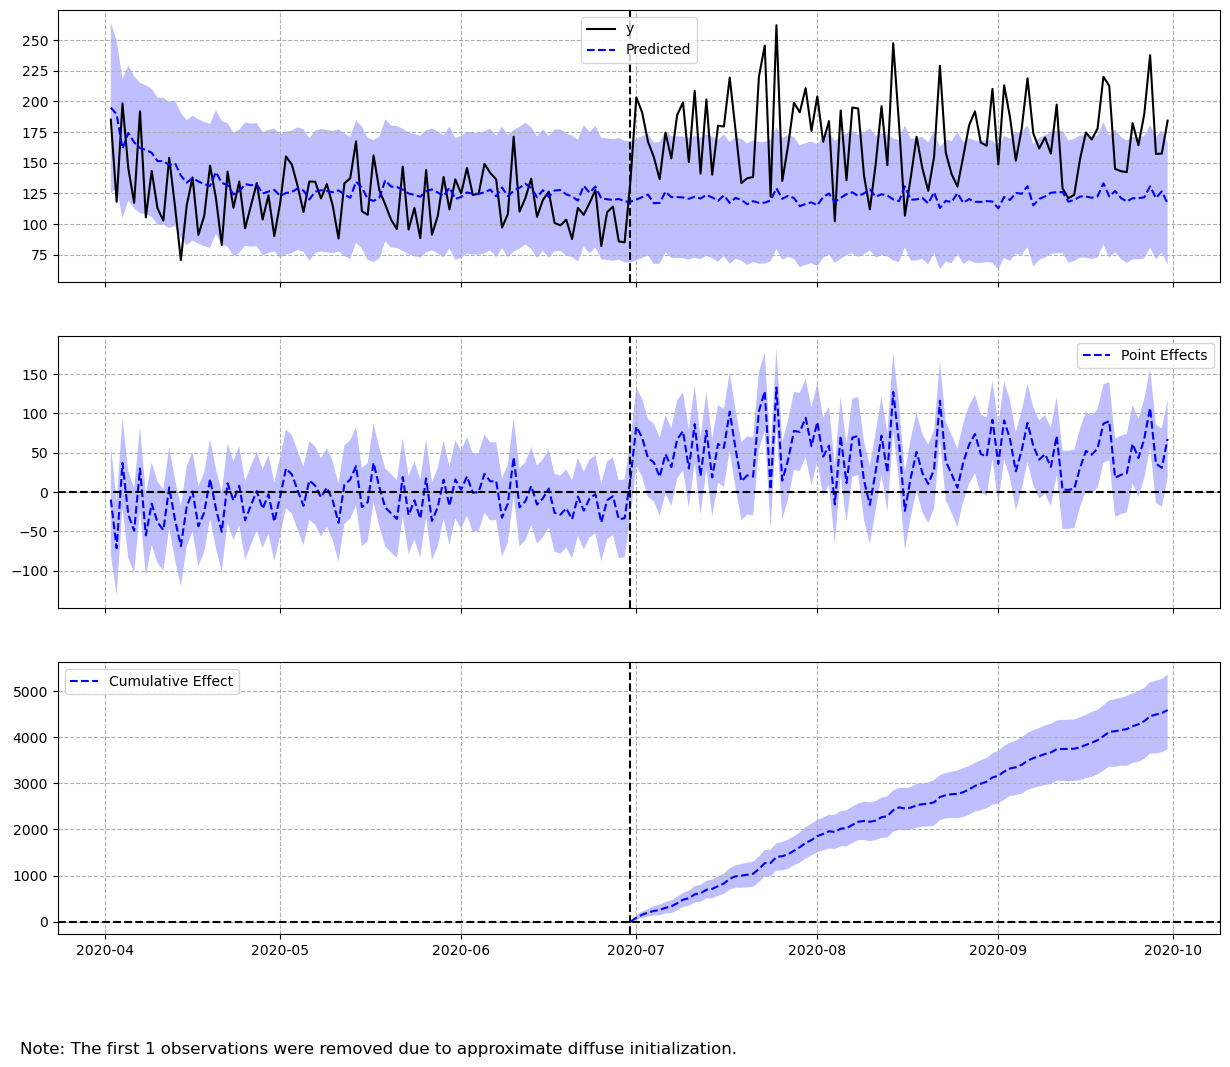

In [10]:
ci.plot()

## Extract the summary statistics and report

In [11]:
print(ci.summary())

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    171.33             15762.67
Prediction (s.d.)         121.42 (4.49)      11170.19 (413.42)
95% CI                    [113.07, 130.68]   [10402.05, 12022.64]

Absolute effect (s.d.)    49.92 (4.49)       4592.48 (413.42)
95% CI                    [40.65, 58.27]     [3740.04, 5360.62]

Relative effect (s.d.)    41.11% (3.7%)      41.11% (3.7%)
95% CI                    [33.48%, 47.99%]   [33.48%, 47.99%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


In [12]:
print(ci.summary(output = "report"))

Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 171.33. By contrast, in the absence of an
intervention, we would have expected an average response of 121.42.
The 95% interval of this counterfactual prediction is [113.07, 130.68].
Subtracting this prediction from the observed response yields
an estimate of the causal effect the intervention had on the
response variable. This effect is 49.92 with a 95% interval of
[40.65, 58.27]. For a discussion of the significance of this effect,
see below.


Summing up the individual data points during the post-intervention
period (which can only sometimes be meaningfully interpreted), the
response variable had an overall value of 15762.67.
By contrast, had the intervention not taken place, we would have expected
a sum of 11170.19. The 95% interval of this prediction is [10402.05, 12022.64].


The above results are given in terms of absolute numbers. In relative
terms, the res